# CLASIFICACIÓN MULTICLASE DE CIBERATAQUES
# Trabajado por Alberto Jesús Prado Agurto

## FUENTE: https://www.kaggle.com/datasets/tannubarot/cybersecurity-attack-and-defence-dataset/data

## Dataset: `attack_dataset_cleaned.csv`
---
**Objetivo:** Entrenar y evaluar modelos de Machine Learning para clasificar el tipo de categoría de ciberataque a partir de características estructuradas extraídas del dataset.

**Variable Target:** `Category` (28 clases — categorías de ciberataques)

**Pipeline:**
1. Diagnóstico del dataset
2. Ingeniería de características
3. División train/test estratificada
4. Entrenamiento (Random Forest · Logistic Regression · XGBoost)
5. Evaluación multiclase completa (Precision, Recall, F1, Kappa, Confusion Matrix)

## 0. IMPORTACIÓN DE LIBRERÍAS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    log_loss
)
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
import joblib

In [ ]:
np.random.seed(42)
sns.set_style('whitegrid')

print('='*65)
print('  CLASIFICACIÓN MULTICLASE DE CIBERATAQUES')
print('  Dataset: attack_dataset_cleaned.csv')
print('='*65)

  CLASIFICACIÓN MULTICLASE DE CIBERATAQUES
  Dataset: attack_dataset_cleaned.csv


## 1. CARGA DEL DATASET

In [ ]:
# Rutas de búsqueda para compatibilidad local y Colab/Kaggle
possible_paths = [
    'attack_dataset_cleaned.csv',
    '/content/attack_dataset_cleaned.csv',
    '/kaggle/input/cybersecurity-attack-and-defence-dataset/attack_dataset_cleaned.csv',
]

In [ ]:
df_raw = None
for p in possible_paths:
    try:
        df_raw = pd.read_csv(p)
        print(f'Dataset cargado desde: {p}')
        break
    except FileNotFoundError:
        continue

if df_raw is None:
    raise FileNotFoundError('No se encontró attack_dataset_cleaned.csv. Verifica la ruta.')

print(f'Shape: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f'Memoria: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
df_raw.head(3)

Dataset cargado desde: attack_dataset_cleaned.csv
Shape: 14,133 filas × 16 columnas
Memoria: 35.32 MB


,ID,Title,Category,Attack Type,Scenario Description,Tools Used,Attack Steps,Target Type,Vulnerability,MITRE Technique,Impact,Detection Method,Solution,Tags,Source,Unnamed: 15
0,1,Authentication Bypass via SQL Injection,Mobile Security,SQL Injection (SQLi),A login form fails to validate or sanitize inp...,"Browser, Burp Suite, SQLMap",1. Reconnaissance: Find a login form on the we...,"Web Login Portals (e.g., banking, admin dashbo...",Unsanitized input fields in SQL queries,"T1078 (Valid Accounts), T1190 (Exploit Public-...","Full account takeover, data theft, privilege e...","Web server logs, anomaly detection (e.g., logi...","Use prepared statements, Sanitize inputs, Limi...","SQLi, Authentication Bypass, Web Security, OWA...","OWASP, MITRE ATT&CK, DVWA",Educational Simulation
1,2,Union-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when a hacker uses the SQL ...,"SQLMap, Burp Suite, Havij, Browser Developer T...",1. Identify User Input Points: Attacker finds ...,"Web Applications, Login Pages, Search Forms",Improperly filtered input fields that allow SQ...,T1190 – Exploit Public-Facing Application,"Data leakage, Credential theft, Account takeov...",Web Application Firewalls (WAF)Log AnalysisInp...,Use parameterized queries (Prepared Statements...,#SQLInjection #WebSecurity #UnionAttack #OWASP...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",Educational Simulation
2,3,Error-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when an attacker intentiona...,"SQLMap, Burp Suite, Manual Browser Testing, Havij",1. Identify Input Points:Attacker finds a fiel...,"Web Applications, Login Forms, URL Parameters,...",Error message exposure due to lack of input va...,T1190 – Exploit Public-Facing Application,"Information disclosure, Database structure exp...",Review and monitor error logsEnable generic er...,Turn off detailed error messages in production...,#SQLInjection #ErrorLeakage #WebAppSecurity #O...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",Educational Simulation


## 2. DIAGNÓSTICO DEL DATASET

In [ ]:
print('Tipos de datos y cardinalidad')
print('-'*50)
for col in df_raw.columns:
    dtype = df_raw[col].dtype
    n_unique = df_raw[col].nunique()
    n_null = df_raw[col].isnull().sum()
    print(f'  {col:<30} dtype={str(dtype):<8}  únicos={n_unique:>5}  nulos={n_null}')

print()
print('Valores nulos totales:', df_raw.isnull().sum().sum())
print()
print('Filas duplicadas:', df_raw.duplicated().sum())

[2.1] Tipos de datos y cardinalidad
--------------------------------------------------
  ID                             dtype=int64     únicos=14133  nulos=0
  Title                          dtype=object    únicos=13793  nulos=0
  Category                       dtype=object    únicos=   64  nulos=0
  Attack Type                    dtype=object    únicos= 8834  nulos=0
  Scenario Description           dtype=object    únicos=13866  nulos=0
  Tools Used                     dtype=object    únicos=12935  nulos=0
  Attack Steps                   dtype=object    únicos=13895  nulos=0
  Target Type                    dtype=object    únicos= 9885  nulos=0
  Vulnerability                  dtype=object    únicos=13424  nulos=0
  MITRE Technique                dtype=object    únicos= 5770  nulos=0
  Impact                         dtype=object    únicos=13187  nulos=0
  Detection Method               dtype=object    únicos=13813  nulos=0
  Solution                       dtype=object    únicos=13852

### Observaciones del diagnóstico

| Columna | Situación | Acción |
|---------|-----------|--------|
| `ID` | Índice secuencial, no aporta información predictiva | **Descartar** |
| `Category` | Variable target — 64 valores con subcategorías (`→`) | **Normalizar como target** |
| `Attack Type` | 8,834 valores únicos (demasiado específico por fila) | **Descartar** |
| `MITRE Technique` | Códigos T-XXXX — extraer el primero (363 únicos) | **Extraer + Encode** |
| `Tools Used` | Multi-valor separado por coma — extraer primero y agrupar | **Extraer + Agrupar** |
| `Target Type` | Multi-valor — extraer primero y agrupar | **Extraer + Agrupar** |
| `Source` | Multi-valor — extraer primero y agrupar | **Extraer + Agrupar** |
| `Unnamed: 15` | 2 valores únicos (artefacto CSV) | **Descartar** |
| Resto | Texto libre de alta cardinalidad (>10k únicos) | **Descartar** |

> **Nota técnica:** Este dataset es de naturaleza NLP. En producción se usaría TF-IDF o embeddings sobre los textos completos. Para este pipeline académico se extraen valores estructurados de los campos más informativos.

## 3. INGENIERÍA DE CARACTERÍSTICAS Y VARIABLE TARGET

### 3.1 NORMALIZACIÓN DE LA VARIABLE TARGET
### Muchas filas tienen subcategorías concatenadas con '→' o '->'.
### Ejemplo: 'Browser Security → Cross-Site Scripting (XSS)' → 'Browser Security'

In [ ]:
df = df_raw.copy()

def normalize_category(cat):
    for sep in [' → ', ' -> ', '→']:
        if sep in str(cat):
            return cat.split(sep)[0].strip()
    return str(cat).strip()

df['Category_Clean'] = df['Category'].apply(normalize_category)

### Unificar variantes menores de la misma categoría

In [ ]:
aliases = {
    'Automotive / CPS': 'Automotive / Cyber-Physical Systems',
    'Network security': 'Network Security',
    ' Mobile Security': 'Mobile Security',
}
df['Category_Clean'] = df['Category_Clean'].replace(aliases)

print('[3.1] Distribución de clases tras normalización:')
print(f'  Clases originales: {df["Category"].nunique()}')
print(f'  Clases normalizadas: {df["Category_Clean"].nunique()}')
print()
vc = df['Category_Clean'].value_counts()
print(vc.to_string())

[3.1] Distribución de clases tras normalización:
  Clases originales: 64
  Clases normalizadas: 28

Category_Clean
Insider Threat                                 569
Physical / Hardware Attacks                    548
Quantum Cryptography & Post-Quantum Threats    542
Wireless Attacks (Advanced)                    535
Malware & Threat                               528
Zero-Day Research / Fuzzing                    520
Satellite & Space Infrastructure Security      515
DFIR                                           510
Automotive / Cyber-Physical Systems            505
Blockchain / Web3                              503
Red Team                                       503
Blue Team                                      503
AI Data Leakage & Privacy Risks                502
Cloud Security                                 501
Operating System Exploits                      501
Web Application Security                       501
Cryptography Attacks                           501
Network Security  

### 3.2 EXTRACCIÓN DE CARACTERÍSTICAS

### Primer código MITRE ATT&CK (ej. T1078, T1190)

In [ ]:
def extract_first_mitre(val):
    match = re.search(r'T\d{4}', str(val))
    return match.group() if match else 'Unknown'

df['feat_mitre'] = df['MITRE Technique'].apply(extract_first_mitre)

# Primer valor de campos multi-valor (separados por coma)
df['feat_tool']   = df['Tools Used'].str.split(',').str[0].str.strip()
df['feat_target'] = df['Target Type'].str.split(',').str[0].str.strip()
df['feat_source'] = df['Source'].str.split(',').str[0].str.strip()

print('Cardinalidad tras extracción de primer valor:')
for col in ['feat_mitre', 'feat_tool', 'feat_target', 'feat_source']:
    print(f'  {col}: {df[col].nunique()} valores únicos')

[3.2] Cardinalidad tras extracción de primer valor:
  feat_mitre: 363 valores únicos
  feat_tool: 5486 valores únicos
  feat_target: 9173 valores únicos
  feat_source: 4829 valores únicos


###  3.3 AGRUPACIÓN DE CATEGORÍAS RARAS (Top-N + "Other")
### Reduce cardinalidad de feat_tool, feat_target y feat_source
### manteniendo los valores más frecuentes y agrupando el resto.

In [ ]:
def group_top_n(series, top_n=50, other_label='Other'):
    top_values = series.value_counts().nlargest(top_n).index
    return series.where(series.isin(top_values), other=other_label)

df['feat_tool']   = group_top_n(df['feat_tool'],   top_n=50)
df['feat_target'] = group_top_n(df['feat_target'], top_n=30)
df['feat_source'] = group_top_n(df['feat_source'], top_n=30)

print('Cardinalidad tras agrupación Top-N:')
for col in ['feat_mitre', 'feat_tool', 'feat_target', 'feat_source']:
    print(f'  {col}: {df[col].nunique()} valores únicos')

[3.3] Cardinalidad tras agrupación Top-N:
  feat_mitre: 363 valores únicos
  feat_tool: 51 valores únicos
  feat_target: 31 valores únicos
  feat_source: 31 valores únicos


#  3.4 LABEL ENCODING DE CARACTERÍSTICAS

In [ ]:
feature_cols = ['feat_mitre', 'feat_tool', 'feat_target', 'feat_source']

feature_encoders = {}
for col in feature_cols:
    le_feat = LabelEncoder()
    df[col] = le_feat.fit_transform(df[col].astype(str))
    feature_encoders[col] = le_feat

# Preparar X e y
X = df[feature_cols].copy()
y_raw = df['Category_Clean'].copy()

# Label Encoding del target
le_target = LabelEncoder()
y = le_target.fit_transform(y_raw)

print('Feature matrix y target:')
print(f'  X shape: {X.shape}')
print(f'  y shape: {y.shape}')
print(f'  Número de clases: {len(le_target.classes_)}')
print()
print('Clases (label → nombre):')
for idx, name in enumerate(le_target.classes_):
    count = (y == idx).sum()
    print(f'  {idx:>2}: {name:<50} ({count:,} muestras)')

[3.4] Feature matrix y target:
  X shape: (14133, 4)
  y shape: (14133,)
  Número de clases: 28

Clases (label → nombre):
   0: AI Agents & LLM Exploits                           (494 muestras)
   1: AI Data Leakage & Privacy Risks                    (502 muestras)
   2: AI/ML Security                                     (496 muestras)
   3: Automotive / Cyber-Physical Systems                (505 muestras)
   4: Blockchain / Web3                                  (503 muestras)
   5: Blue Team                                          (503 muestras)
   6: Browser Security                                   (490 muestras)
   7: Cloud Security                                     (501 muestras)
   8: Cryptography Attacks                               (501 muestras)
   9: DFIR                                               (510 muestras)
  10: DevSecOps & CI/CD Security                         (479 muestras)
  11: Email & Messaging Protocol Exploits                (500 muestras)
  12: Insider 

## 4. ANÁLISIS DE DESBALANCEO DE CLASES

In [ ]:
class_counts = pd.Series(y).value_counts().sort_index()
class_names  = le_target.classes_
class_pct    = class_counts / len(y) * 100

print('Diagnóstico de desbalanceo:')
print(f'  Clase más frecuente:  {class_names[class_counts.idxmax()]} ({class_counts.max():,} muestras)')
print(f'  Clase menos frecuente: {class_names[class_counts.idxmin()]} ({class_counts.min():,} muestras)')
print(f'  Ratio máx/mín: {class_counts.max()/class_counts.min():.2f}x')
print(f'  Coeficiente de variación: {class_counts.std()/class_counts.mean()*100:.1f}%')
print()

[4] Diagnóstico de desbalanceo:
  Clase más frecuente:  Insider Threat (569 muestras)
  Clase menos frecuente: SCADA/ICS (452 muestras)
  Ratio máx/mín: 1.26x
  Coeficiente de variación: 4.9%



In [ ]:
# Un ratio < 2x y CV < 20% indica dataset bien balanceado
ratio = class_counts.max() / class_counts.min()
if ratio < 2.0:
    print('  DATASET BALANCEADO: ratio máx/mín < 2x.')
    print('  Se aplica class_weight="balanced" por precaución académica.')
else:
    print('  DATASET DESBALANCEADO: se requiere class_weight="balanced" o SMOTE.')

  DATASET BALANCEADO: ratio máx/mín < 2x.
  Se aplica class_weight="balanced" por precaución académica.


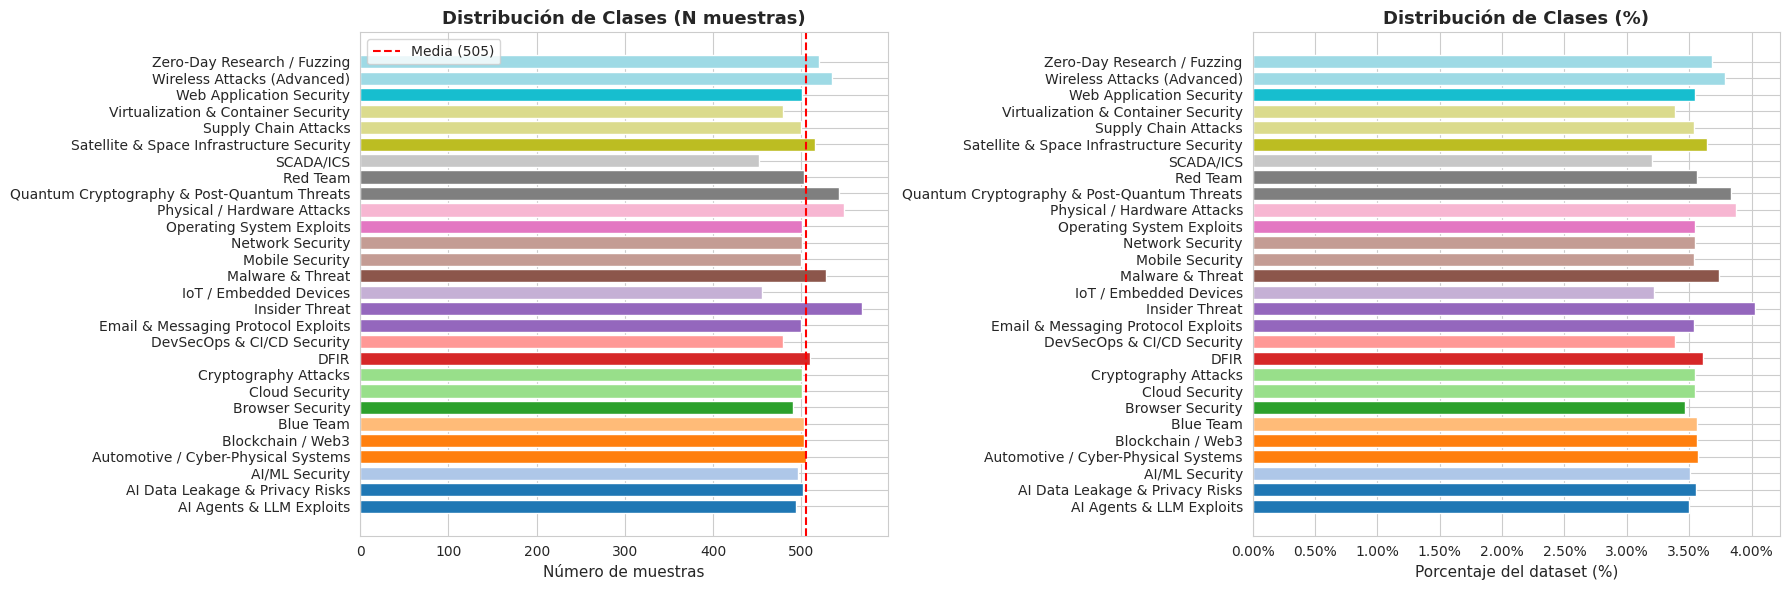

In [ ]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Barras horizontales
colors = plt.cm.tab20(np.linspace(0, 1, len(class_names)))
axes[0].barh(class_names[class_counts.index], class_counts.values, color=colors)
axes[0].set_xlabel('Número de muestras', fontsize=11)
axes[0].set_title('Distribución de Clases (N muestras)', fontsize=13, fontweight='bold')
axes[0].axvline(class_counts.mean(), color='red', linestyle='--', label=f'Media ({class_counts.mean():.0f})')
axes[0].legend()

# Distribución porcentual
axes[1].barh(class_names[class_counts.index], class_pct.values, color=colors)
axes[1].set_xlabel('Porcentaje del dataset (%)', fontsize=11)
axes[1].set_title('Distribución de Clases (%)', fontsize=13, fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
#plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. DIVISIÓN TRAIN / TEST ESTRATIFICADA

### Escalado estándar — necesario para Logistic Regression.
### Random Forest y XGBoost son invariantes al escalado, pero
### usamos el mismo X_scaled para todos los modelos por consistencia.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split estratificado: mantiene la proporción de clases en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('División del dataset:')
print(f'  Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.1f}%)')
print(f'  Test:  {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(y)*100:.1f}%)')
print(f'  Features: {X_train.shape[1]}')
print()
print('Verificación de distribución estratificada (train vs test):')
train_pct = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_pct  = pd.Series(y_test).value_counts(normalize=True).sort_index()
check_df  = pd.DataFrame({'Train%': train_pct*100, 'Test%': test_pct*100})
check_df.index = [le_target.classes_[i] for i in check_df.index]
print(check_df.round(2).to_string())

[5] División del dataset:
  Train: 11,306 muestras (80.0%)
  Test:  2,827 muestras (20.0%)
  Features: 4

Verificación de distribución estratificada (train vs test):
                                             Train%  Test%
AI Agents & LLM Exploits                       3.49   3.50
AI Data Leakage & Privacy Risks                3.56   3.54
AI/ML Security                                 3.51   3.50
Automotive / Cyber-Physical Systems            3.57   3.57
Blockchain / Web3                              3.56   3.57
Blue Team                                      3.56   3.57
Browser Security                               3.47   3.47
Cloud Security                                 3.55   3.54
Cryptography Attacks                           3.55   3.54
DFIR                                           3.61   3.61
DevSecOps & CI/CD Security                     3.39   3.40
Email & Messaging Protocol Exploits            3.54   3.54
Insider Threat                                 4.02   4.03
IoT / Em

## 6. CONFIGURACIÓN DE PESOS DE CLASE
Aunque el dataset está balanceado, aplicar `class_weight='balanced'` es buena práctica en clasificación multiclase de ciberseguridad.

In [ ]:
classes_unique = np.unique(y_train)
class_weights_arr = compute_class_weight('balanced', classes=classes_unique, y=y_train)
class_weight_dict = dict(zip(classes_unique, class_weights_arr))

print('Pesos de clase calculados (balanced):')
for cls_idx, weight in class_weight_dict.items():
    print(f'  Clase {cls_idx:>2} | {le_target.classes_[cls_idx]:<50} | peso: {weight:.4f}')

[6] Pesos de clase calculados (balanced):
  Clase  0 | AI Agents & LLM Exploits                           | peso: 1.0222
  Clase  1 | AI Data Leakage & Privacy Risks                    | peso: 1.0044
  Clase  2 | AI/ML Security                                     | peso: 1.0171
  Clase  3 | Automotive / Cyber-Physical Systems                | peso: 0.9995
  Clase  4 | Blockchain / Web3                                  | peso: 1.0044
  Clase  5 | Blue Team                                          | peso: 1.0044
  Clase  6 | Browser Security                                   | peso: 1.0301
  Clase  7 | Cloud Security                                     | peso: 1.0069
  Clase  8 | Cryptography Attacks                               | peso: 1.0069
  Clase  9 | DFIR                                               | peso: 0.9897
  Clase 10 | DevSecOps & CI/CD Security                         | peso: 1.0543
  Clase 11 | Email & Messaging Protocol Exploits                | peso: 1.0095
  Clase 12

## 7. ENTRENAMIENTO DE MODELOS

### 7.1 Random Forest

In [ ]:
print('Entrenando Random Forest...')

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred_train = rf_model.predict(X_train)
rf_pred_test  = rf_model.predict(X_test)

rf_train_acc = accuracy_score(y_train, rf_pred_train)
rf_test_acc  = accuracy_score(y_test,  rf_pred_test)

print(f'  Train Accuracy: {rf_train_acc:.4f}')
print(f'  Test  Accuracy: {rf_test_acc:.4f}')
if rf_train_acc - rf_test_acc > 0.10:
    print(f'  ADVERTENCIA: posible overfitting (gap {(rf_train_acc-rf_test_acc)*100:.1f}%)')
else:
    print('  Generalización correcta (gap < 10%)')
print('  Entrenamiento completado.')

[7.1] Entrenando Random Forest...
  Train Accuracy: 0.5831
  Test  Accuracy: 0.4977
  Generalización correcta (gap < 10%)
  Entrenamiento completado.


### 7.2 Logistic Regression

In [ ]:
print('Entrenando Logistic Regression...')

# multinomial con solver lbfgs es el estándar para multiclase con sklearn
lr_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='lbfgs',
    multi_class='multinomial',
    C=1.0,
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train, y_train)

lr_pred_train = lr_model.predict(X_train)
lr_pred_test  = lr_model.predict(X_test)

lr_train_acc = accuracy_score(y_train, lr_pred_train)
lr_test_acc  = accuracy_score(y_test,  lr_pred_test)

print(f'  Train Accuracy: {lr_train_acc:.4f}')
print(f'  Test  Accuracy: {lr_test_acc:.4f}')
print('  Entrenamiento completado.')

[7.2] Entrenando Logistic Regression...
  Train Accuracy: 0.1364
  Test  Accuracy: 0.1309
  Entrenamiento completado.


### 7.3 XGBoost

In [ ]:
print('Entrenando XGBoost...')

# XGBoost requiere que el target sea 0..N-1 (ya lo tenemos así con LabelEncoder)
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

xgb_pred_train = xgb_model.predict(X_train)
xgb_pred_test  = xgb_model.predict(X_test)

xgb_train_acc = accuracy_score(y_train, xgb_pred_train)
xgb_test_acc  = accuracy_score(y_test,  xgb_pred_test)

print(f'  Train Accuracy: {xgb_train_acc:.4f}')
print(f'  Test  Accuracy: {xgb_test_acc:.4f}')
print('  Entrenamiento completado.')

[7.3] Entrenando XGBoost...
  Train Accuracy: 0.5938
  Test  Accuracy: 0.5034
  Entrenamiento completado.


## 8. MÉTRICAS MULTICLASE — COMPARATIVA COMPLETA

In [ ]:
# Función de evaluación estandarizada
def evaluate_model(name, y_true, y_pred, y_prob=None):
    """Calcula métricas multiclase completas para un modelo."""
    metrics = {
        'Modelo':           name,
        'Accuracy':         accuracy_score(y_true, y_pred),
        'Precision_macro':  precision_score(y_true, y_pred, average='macro',    zero_division=0),
        'Precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall_macro':     recall_score(y_true, y_pred, average='macro',    zero_division=0),
        'Recall_weighted':  recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1_macro':         f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'F1_weighted':      f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'Cohen_Kappa':      cohen_kappa_score(y_true, y_pred),
    }
    if y_prob is not None:
        metrics['Log_Loss'] = log_loss(y_true, y_prob)
    return metrics

# Obtener probabilidades para Log-Loss
rf_proba  = rf_model.predict_proba(X_test)
lr_proba  = lr_model.predict_proba(X_test)
xgb_proba = xgb_model.predict_proba(X_test)

results_list = [
    evaluate_model('Random Forest',       y_test, rf_pred_test,  rf_proba),
    evaluate_model('Logistic Regression', y_test, lr_pred_test,  lr_proba),
    evaluate_model('XGBoost',             y_test, xgb_pred_test, xgb_proba),
]

results_df = pd.DataFrame(results_list).set_index('Modelo')

print('COMPARATIVA DE MODELOS — TEST SET')
print('='*80)
print(results_df.round(4).to_string())
print()
print('Mejor modelo por F1-macro:', results_df['F1_macro'].idxmax())
print('Mejor modelo por Cohen Kappa:', results_df['Cohen_Kappa'].idxmax())

[8] COMPARATIVA DE MODELOS — TEST SET
                     Accuracy  Precision_macro  Precision_weighted  Recall_macro  Recall_weighted  F1_macro  F1_weighted  Cohen_Kappa  Log_Loss
Modelo                                                                                                                                         
Random Forest          0.4977           0.5079              0.5077        0.4972           0.4977    0.4959       0.4962       0.4790    1.7208
Logistic Regression    0.1309           0.1624              0.1669        0.1307           0.1309    0.0886       0.0888       0.0985    3.0867
XGBoost                0.5034           0.5120              0.5119        0.5023           0.5034    0.5027       0.5033       0.4849    1.6197

Mejor modelo por F1-macro: XGBoost
Mejor modelo por Cohen Kappa: XGBoost


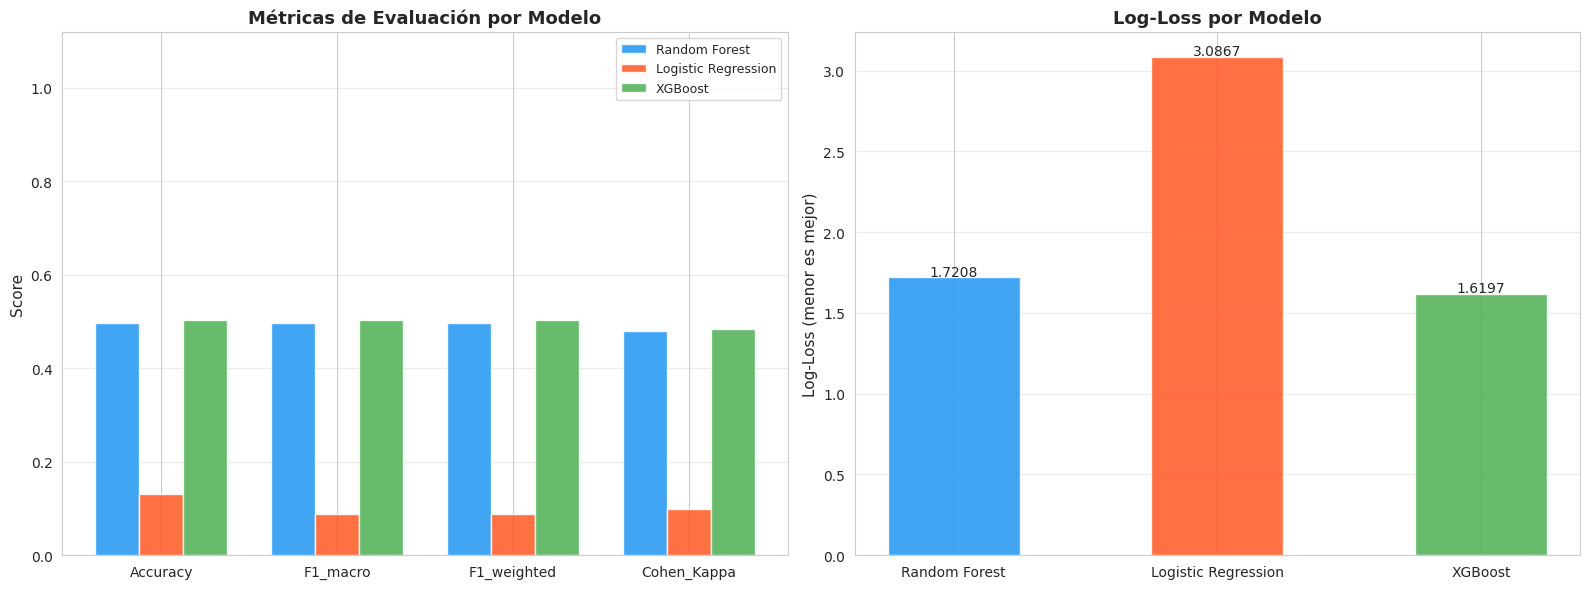

In [ ]:
# Visualización comparativa de métricas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: métricas clave por modelo
metrics_to_plot = ['Accuracy', 'F1_macro', 'F1_weighted', 'Cohen_Kappa']
plot_data = results_df[metrics_to_plot].T

x = np.arange(len(metrics_to_plot))
width = 0.25
colors_bar = ['#2196F3', '#FF5722', '#4CAF50']

for i, model_name in enumerate(plot_data.columns):
    axes[0].bar(x + i*width, plot_data[model_name], width,
                label=model_name, color=colors_bar[i], alpha=0.85)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot, fontsize=10)
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Métricas de Evaluación por Modelo', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.4)

# Gráfico 2: Log-Loss (menor es mejor)
log_losses = results_df['Log_Loss']
bars = axes[1].bar(log_losses.index, log_losses.values,
                   color=colors_bar, alpha=0.85, width=0.5)
axes[1].set_ylabel('Log-Loss (menor es mejor)', fontsize=11)
axes[1].set_title('Log-Loss por Modelo', fontsize=13, fontweight='bold')
for bar, val in zip(bars, log_losses.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=10)
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. ANÁLISIS DETALLADO DEL MEJOR MODELO
### Justificación de métricas en clasificación multiclase desbalanceada:
- **F1-macro:** trata todas las clases con igual peso — penaliza duramente las clases minoritarias.
- **F1-weighted:** promedio ponderado por frecuencia — refleja el rendimiento global real.
- **Cohen's Kappa:** mide el acuerdo del modelo vs. un clasificador aleatorio. κ > 0.8 = excelente.
- **Log-Loss:** penaliza la incertidumbre en las probabilidades — útil para modelos probabilísticos.

In [ ]:
# Selección automática del mejor modelo por F1-macro
best_model_name = results_df['F1_macro'].idxmax()
model_map = {
    'Random Forest':       (rf_model,  rf_pred_test,  rf_proba),
    'Logistic Regression': (lr_model,  lr_pred_test,  lr_proba),
    'XGBoost':             (xgb_model, xgb_pred_test, xgb_proba),
}
best_model, best_pred, best_proba = model_map[best_model_name]

print(f'MEJOR MODELO: {best_model_name}')
print(f'  F1-macro:    {results_df.loc[best_model_name, "F1_macro"]:.4f}')
print(f'  F1-weighted: {results_df.loc[best_model_name, "F1_weighted"]:.4f}')
print(f'  Kappa:       {results_df.loc[best_model_name, "Cohen_Kappa"]:.4f}')
print(f'  Log-Loss:    {results_df.loc[best_model_name, "Log_Loss"]:.4f}')

MEJOR MODELO: XGBoost
  F1-macro:    0.5027
  F1-weighted: 0.5033
  Kappa:       0.4849
  Log-Loss:    1.6197


### 9.1 Matriz de Confusión

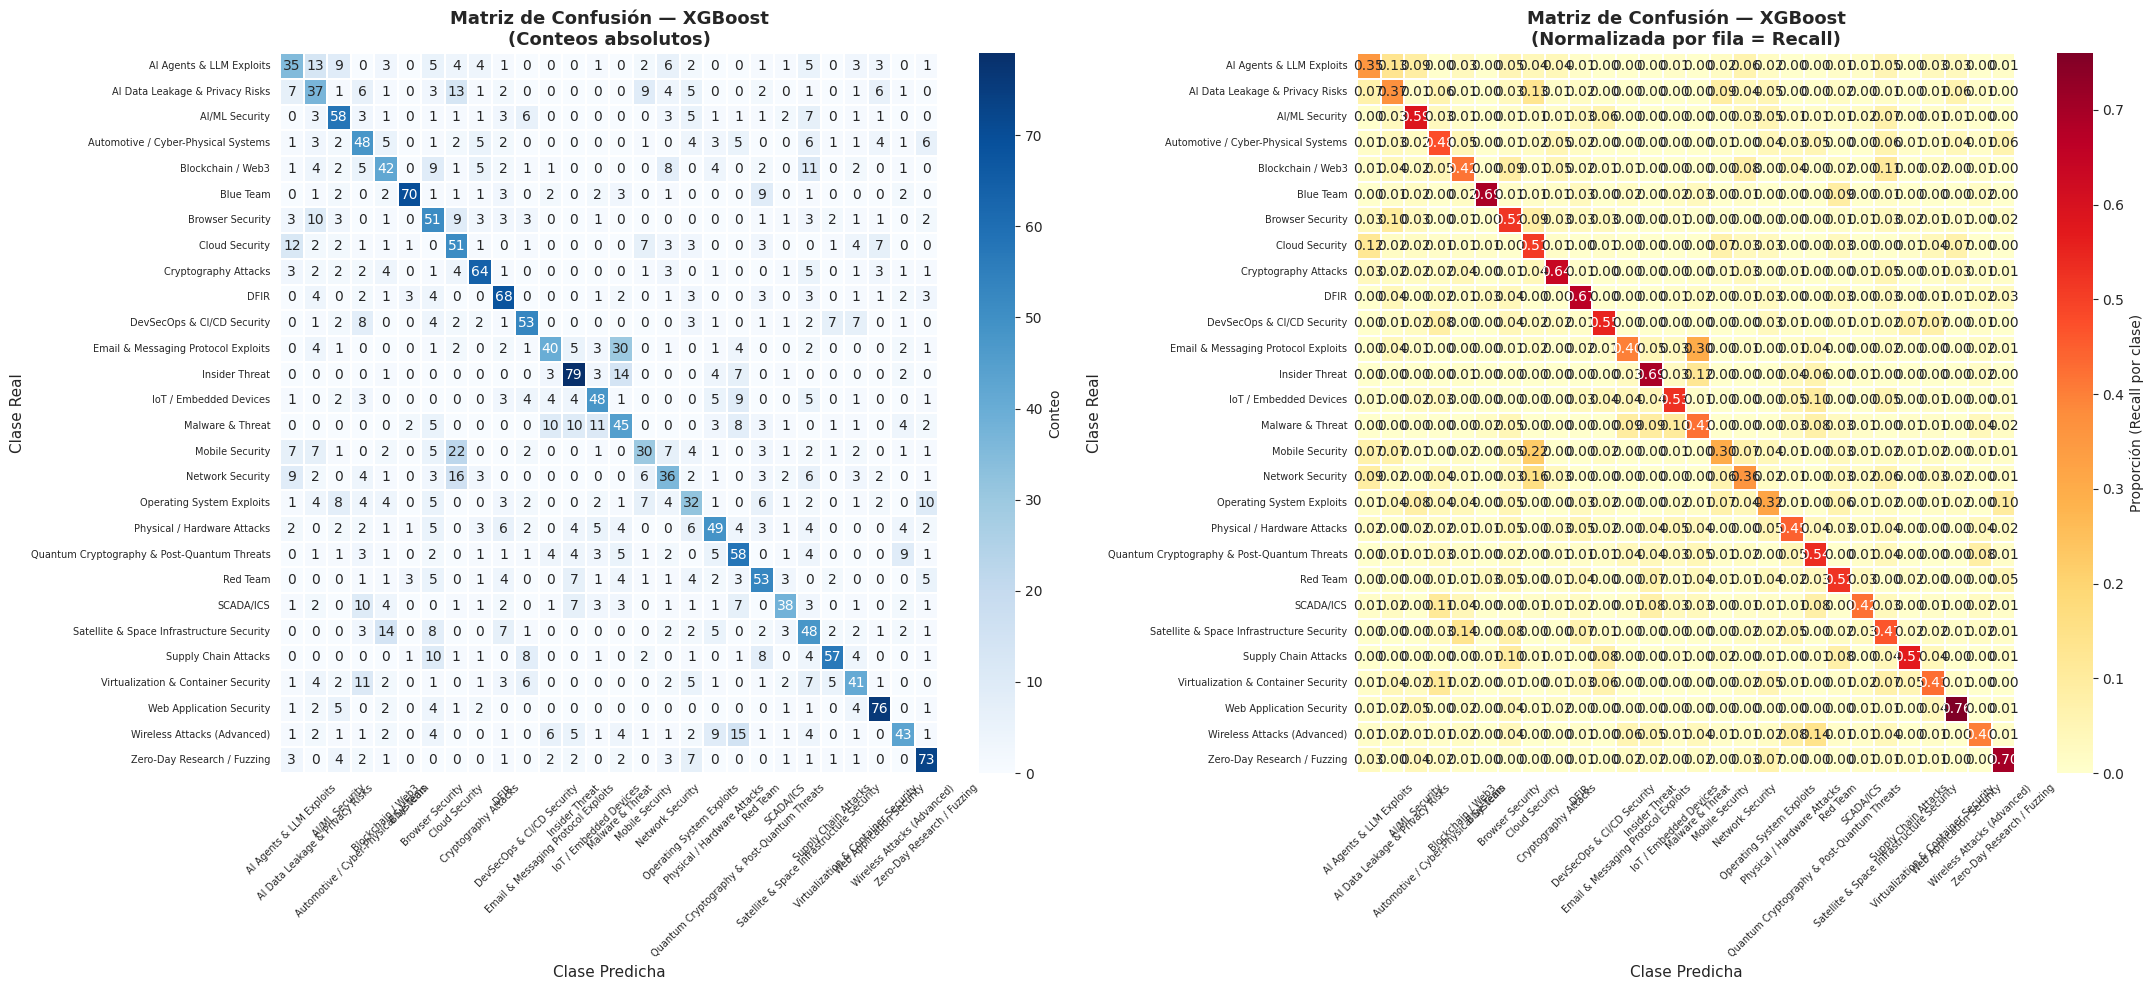

In [ ]:
cm = confusion_matrix(y_test, best_pred)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Matriz de confusión — conteos absolutos
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le_target.classes_, yticklabels=le_target.classes_,
    ax=axes[0], cbar_kws={'label': 'Conteo'}, linewidths=0.3
)
axes[0].set_title(f'Matriz de Confusión — {best_model_name}\n(Conteos absolutos)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Clase Real', fontsize=11)
axes[0].set_xlabel('Clase Predicha', fontsize=11)
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', rotation=0,  labelsize=7)

# Matriz normalizada por fila (Recall por clase)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=le_target.classes_, yticklabels=le_target.classes_,
    ax=axes[1], cbar_kws={'label': 'Proporción (Recall por clase)'}, linewidths=0.3
)
axes[1].set_title(f'Matriz de Confusión — {best_model_name}\n(Normalizada por fila = Recall)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Clase Real', fontsize=11)
axes[1].set_xlabel('Clase Predicha', fontsize=11)
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
#plt.savefig('confusion_matrix_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.2 Reporte de Clasificación por Clase

In [ ]:
print(f'Classification Report — {best_model_name}')
print('='*80)
print(classification_report(
    y_test, best_pred,
    target_names=le_target.classes_,
    digits=4,
    zero_division=0
))

[9.2] Classification Report — XGBoost
                                             precision    recall  f1-score   support

                   AI Agents & LLM Exploits     0.3933    0.3535    0.3723        99
            AI Data Leakage & Privacy Risks     0.3426    0.3700    0.3558       100
                             AI/ML Security     0.5273    0.5859    0.5550        99
        Automotive / Cyber-Physical Systems     0.4034    0.4752    0.4364       101
                          Blockchain / Web3     0.4330    0.4158    0.4242       101
                                  Blue Team     0.8642    0.6931    0.7692       101
                           Browser Security     0.3696    0.5204    0.4322        98
                             Cloud Security     0.3893    0.5100    0.4416       100
                       Cryptography Attacks     0.6400    0.6400    0.6400       100
                                       DFIR     0.5714    0.6667    0.6154       102
                 DevSecOps

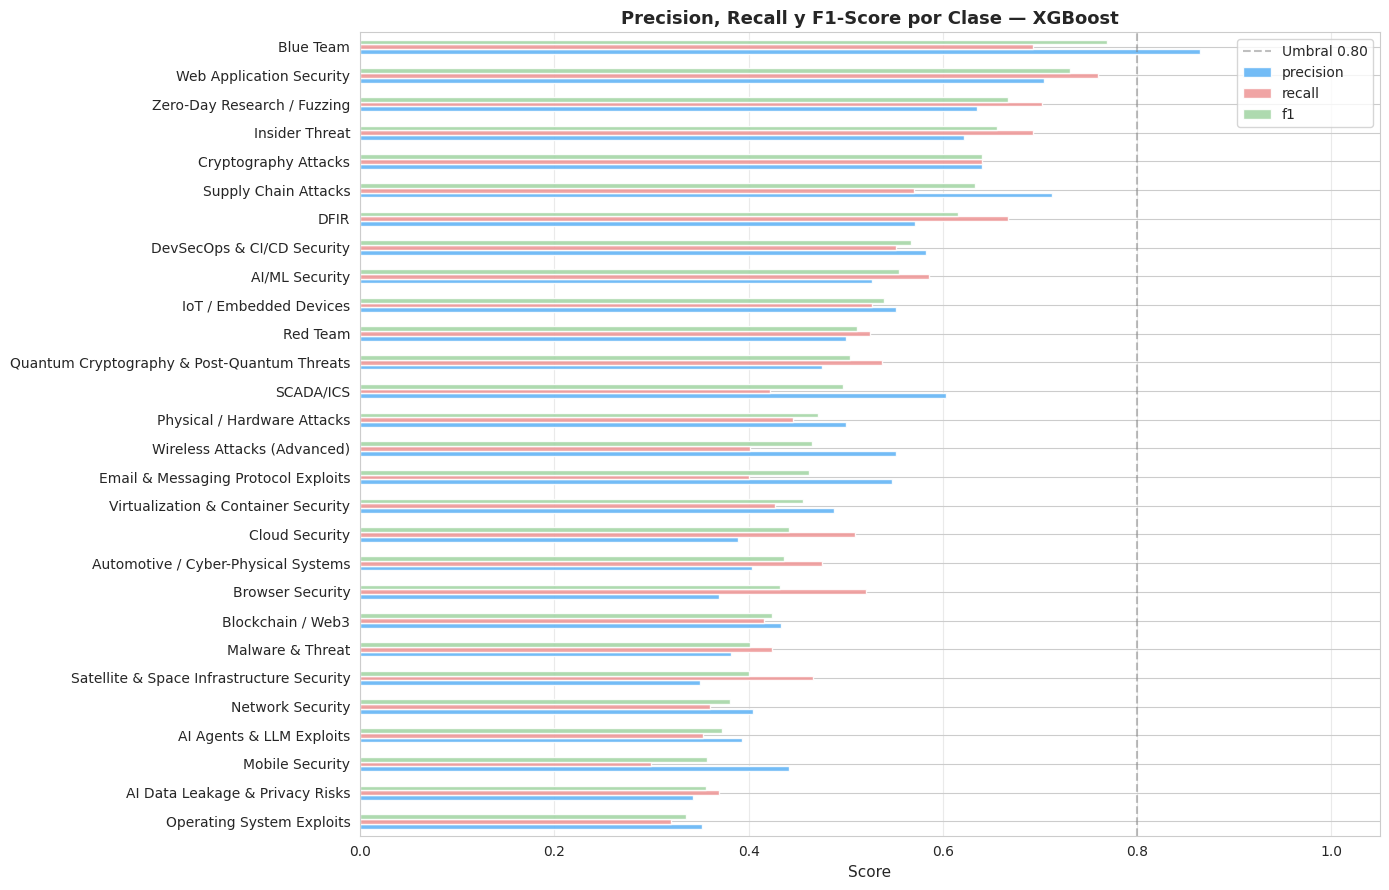

In [ ]:
# Visualizar F1-score por clase para el mejor modelo
report_dict = {}
for i, cls_name in enumerate(le_target.classes_):
    mask = y_test == i
    if mask.sum() > 0:
        report_dict[cls_name] = {
            'precision': precision_score(y_test == i, best_pred == i, zero_division=0),
            'recall':    recall_score(y_test == i, best_pred == i, zero_division=0),
            'f1':        f1_score(y_test == i, best_pred == i, zero_division=0),
        }

report_plot_df = pd.DataFrame(report_dict).T.sort_values('f1')

fig, ax = plt.subplots(figsize=(14, 9))
report_plot_df[['precision', 'recall', 'f1']].plot(
    kind='barh', ax=ax, color=['#64B5F6', '#EF9A9A', '#A5D6A7'], alpha=0.9
)
ax.set_title(f'Precision, Recall y F1-Score por Clase — {best_model_name}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Score', fontsize=11)
ax.set_xlim(0, 1.05)
ax.axvline(0.8, color='gray', linestyle='--', alpha=0.5, label='Umbral 0.80')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
#plt.savefig('f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.3 Cohen's Kappa e Interpretación

In [ ]:
def interpret_kappa(kappa):
    if kappa < 0:    return 'Sin acuerdo'
    elif kappa < 0.20: return 'Acuerdo insignificante'
    elif kappa < 0.40: return 'Acuerdo débil'
    elif kappa < 0.60: return 'Acuerdo moderado'
    elif kappa < 0.80: return 'Acuerdo sustancial'
    else:              return 'Acuerdo casi perfecto'

print('Cohen\'s Kappa — Interpretación por modelo:')
print('-'*60)
for model_name in results_df.index:
    k = results_df.loc[model_name, 'Cohen_Kappa']
    print(f'  {model_name:<25} κ = {k:.4f}  →  {interpret_kappa(k)}')

print()


[9.3] Cohen's Kappa — Interpretación por modelo:
------------------------------------------------------------
  Random Forest             κ = 0.4790  →  Acuerdo moderado
  Logistic Regression       κ = 0.0985  →  Acuerdo insignificante
  XGBoost                   κ = 0.4849  →  Acuerdo moderado

[9.4] Log-Loss — Interpretación:
------------------------------------------------------------
  Log-Loss penaliza la incertidumbre probabilística.
  Un modelo perfecto tiene Log-Loss = 0.
  Random Forest             Log-Loss = 1.7208
  Logistic Regression       Log-Loss = 3.0867
  XGBoost                   Log-Loss = 1.6197


In [ ]:
print('Log-Loss — Interpretación:')
print('-'*60)
print('  Log-Loss penaliza la incertidumbre probabilística.')
print('  Un modelo perfecto tiene Log-Loss = 0.')
for model_name in results_df.index:
    ll = results_df.loc[model_name, 'Log_Loss']
    print(f'  {model_name:<25} Log-Loss = {ll:.4f}')

## 10. IMPORTANCIA DE CARACTERÍSTICAS (Random Forest)

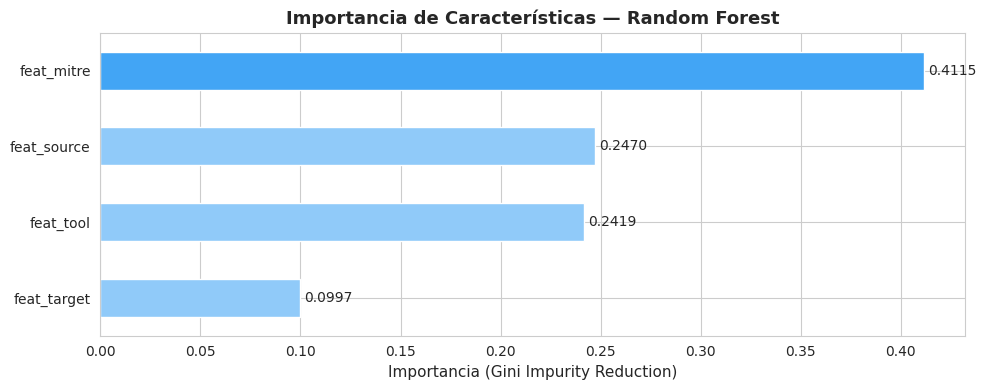

Importancia de cada característica:
  feat_mitre      0.4115  █████████████████████████████████████████
  feat_source     0.2470  ████████████████████████
  feat_tool       0.2419  ████████████████████████
  feat_target     0.0997  █████████


In [ ]:
feat_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
colors_feat = ['#42A5F5' if v == feat_importance.max() else '#90CAF9'
               for v in feat_importance.values]
feat_importance.plot(kind='barh', ax=ax, color=colors_feat)
ax.set_title('Importancia de Características — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (Gini Impurity Reduction)', fontsize=11)

for i, (val, col) in enumerate(zip(feat_importance.values, feat_importance.index)):
    ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
#plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
print('Importancia de cada característica:')
for col, val in feat_importance.sort_values(ascending=False).items():
    bar = '█' * int(val * 100)
    print(f'  {col:<15} {val:.4f}  {bar}')

## 11. RESUMEN EJECUTIVO

In [ ]:
best_row = results_df.loc[best_model_name]

print('='*65)
print('  RESUMEN EJECUTIVO — CLASIFICACIÓN MULTICLASE DE CIBERATAQUES')
print('='*65)
print(f'  Dataset:           attack_dataset_cleaned.csv')
print(f'  Total muestras:    {len(y):,}')
print(f'  Clases objetivo:   {len(le_target.classes_)} categorías de ciberataque')
print(f'  Features usadas:   {X.shape[1]} ({", ".join(feature_cols)})')
print(f'  Train / Test:      {X_train.shape[0]:,} / {X_test.shape[0]:,}')
print()
print(f'  MEJOR MODELO:      {best_model_name}')
print(f'  Accuracy:          {best_row["Accuracy"]:.4f}')
print(f'  F1-Score (macro):  {best_row["F1_macro"]:.4f}')
print(f'  F1-Score (weighted): {best_row["F1_weighted"]:.4f}')
print(f'  Cohen\'s Kappa:    {best_row["Cohen_Kappa"]:.4f}  ({interpret_kappa(best_row["Cohen_Kappa"])})')
print(f'  Log-Loss:          {best_row["Log_Loss"]:.4f}')
print('='*65)

  RESUMEN EJECUTIVO — CLASIFICACIÓN MULTICLASE DE CIBERATAQUES
  Dataset:           attack_dataset_cleaned.csv
  Total muestras:    14,133
  Clases objetivo:   28 categorías de ciberataque
  Features usadas:   4 (feat_mitre, feat_tool, feat_target, feat_source)
  Train / Test:      11,306 / 2,827

  MEJOR MODELO:      XGBoost
  Accuracy:          0.5034
  F1-Score (macro):  0.5027
  F1-Score (weighted): 0.5033
  Cohen's Kappa:    0.4849  (Acuerdo moderado)
  Log-Loss:          1.6197


## 12. GUARDADO DE MODELOS Y ARTEFACTOS

In [ ]:
print('Guardando modelos y artefactos de preprocesamiento...')

# Guardar todos los modelos entrenados
model_artifacts = {
    'rf_model.pkl':  rf_model,
    'lr_model.pkl':  lr_model,
    'xgb_model.pkl': xgb_model,
}
for fname, model_obj in model_artifacts.items():
    joblib.dump(model_obj, fname, compress=3)
    size_mb = os.path.getsize(fname) / 1024**2
    print(f'  Guardado: {fname} ({size_mb:.2f} MB)')

# Guardar preprocesadores
preprocessing_artifacts = {
    'scaler.pkl':           scaler,
    'label_encoder_target.pkl': le_target,
    'feature_encoders.pkl': feature_encoders,
    'feature_names.pkl':    feature_cols,
}
for fname, obj in preprocessing_artifacts.items():
    joblib.dump(obj, fname, compress=3)
    size_mb = os.path.getsize(fname) / 1024**2
    print(f'  Guardado: {fname} ({size_mb:.2f} MB)')

# Guardar resumen de resultados
summary = {
    'best_model':         best_model_name,
    'metrics':            results_df.to_dict(),
    'target_classes':     le_target.classes_.tolist(),
    'feature_columns':    feature_cols,
    'n_samples_train':    int(X_train.shape[0]),
    'n_samples_test':     int(X_test.shape[0]),
    'n_classes':          int(len(le_target.classes_)),
}
joblib.dump(summary, 'results_summary.pkl', compress=3)
print(f'  Guardado: results_summary.pkl')

print()
print('Pipeline completado exitosamente.')

[12] Guardando modelos y artefactos de preprocesamiento...
  Guardado: rf_model.pkl (21.68 MB)
  Guardado: lr_model.pkl (0.00 MB)
  Guardado: xgb_model.pkl (5.51 MB)
  Guardado: scaler.pkl (0.00 MB)
  Guardado: label_encoder_target.pkl (0.00 MB)
  Guardado: feature_encoders.pkl (0.00 MB)
  Guardado: feature_names.pkl (0.00 MB)
  Guardado: results_summary.pkl

Pipeline completado exitosamente.
